In [1]:
from tensorflow.keras.models import Sequential

from tensorflow.keras.layers import (
    Conv2D,
    MaxPooling2D,
    Flatten,
    Dense,
    Dropout,
    BatchNormalization
)

In [2]:
# FACE DETECTION, LANDMARK, FACE ALIGNMENT DAN PREPROCESSING WAJAH

import cv2
import numpy as np
from mtcnn import MTCNN

detector = MTCNN()

# resize proporsional
def resize_keep_ratio(img, max_size=640):

    h, w = img.shape[:2]

    scale = max_size / max(h, w)

    if scale >= 1:
        return img

    new_w = int(w * scale)
    new_h = int(h * scale)

    return cv2.resize(
        img,
        (new_w, new_h)
    )

def detect_face(img):

    # resize proporsional
    img = resize_keep_ratio(img)

    # BGR -> RGB
    rgb = cv2.cvtColor(
        img,
        cv2.COLOR_BGR2RGB
    )

    # detect wajah
    results = detector.detect_faces(rgb)

    # filter confidence
    results = [
        r for r in results
        if r['confidence'] >= 0.8
    ]

    if len(results) == 0:
        return None

    # ambil wajah terbesar
    results = sorted(
        results,
        key=lambda x:
        x['box'][2] * x['box'][3],
        reverse=True
    )

    result = results[0]

    x, y, w, h = result['box']
    
    if w <= 0 or h <= 0:
        return None

    x = max(0, x)
    y = max(0, y)

    # landmark
    try:

        keypoints = result['keypoints']

        left_eye = keypoints['left_eye']
        right_eye = keypoints['right_eye']

    except:
        return None

    # sudut wajah
    dx = right_eye[0] - left_eye[0]
    dy = right_eye[1] - left_eye[1]

    angle = np.degrees(
        np.arctan2(dy, dx)
    )

    # titik tengah mata
    center = (
        int((left_eye[0] + right_eye[0]) / 2),
        int((left_eye[1] + right_eye[1]) / 2)
    )

    # rotate wajah
    M = cv2.getRotationMatrix2D(
        center,
        angle,
        1.0
    )

    aligned = cv2.warpAffine(
        rgb,
        M,
        (rgb.shape[1], rgb.shape[0])
    )

    # padding wajah
    pad = int(min(w, h) * 0.12)

    x1 = max(0, x-pad)
    y1 = max(0, y-pad)

    x2 = min(aligned.shape[1], x+w+pad)
    y2 = min(aligned.shape[0], y+h+pad)

    # crop wajah
    face = aligned[y1:y2, x1:x2]

    if face.size == 0:
        return None

    # CLAHE enhancement untuk memperbaiki kontras
    lab = cv2.cvtColor(
        face,
        cv2.COLOR_RGB2LAB
    )

    l, a, b = cv2.split(lab)

    clahe = cv2.createCLAHE(
        clipLimit=2.0,
        tileGridSize=(8,8)
    )

    l = clahe.apply(l)

    lab = cv2.merge((l,a,b))

    face = cv2.cvtColor(
        lab,
        cv2.COLOR_LAB2RGB
    )

    # resize final
    face = cv2.resize(
        face,
        (128,128),
        interpolation=cv2.INTER_AREA
    )

    face = face.astype("float32")

    return face

In [3]:
def print_progress(val, val_len, folder, bar_size=20):
    progr = "#"*round((val)*bar_size/val_len) + " "*round((val_len - (val))*bar_size/val_len)
    if val == 0:
        print("", end = "\n")
    else:
        print("[%s] (%d samples)\t label : %s \t\t" % (progr, val+1, folder), end="\r")

In [4]:
# LOAD DATASET

import gc
import os
import cv2
import random
import numpy as np

dataset_folder = "Dataset/Dataset_wajah"

names = []
images = []

skipped = 0

print("[INFO] Loading dataset...")

for folder in os.listdir(dataset_folder):

    folder_path = os.path.join(
        dataset_folder,
        folder
    )

    if not os.path.isdir(folder_path):
        continue
    files = os.listdir(folder_path)
    random.shuffle(files)
    used = 0

    for i, name in enumerate(files):

        if not name.lower().endswith(
            (".jpg", ".jpeg", ".png")
        ):
            continue
        img_path = os.path.join(
            folder_path,
            name
        )
        img = cv2.imread(img_path)
        if img is None:
            skipped += 1
            continue

        try:

            # face detection + alignment
            img = detect_face(img)

        except Exception as e:

            print(f"[ERROR] {name}")
            skipped += 1
            continue

        if img is not None:

            images.append(img)

            names.append(folder)

            used += 1

            print_progress(
                i,
                len(files),
                folder
            )

        else:
            skipped += 1

        # bersihkan RAM berkala
        if i % 50 == 0:
            gc.collect()

    print(f"\n[OK] {folder}: {used} images")

# convert ke numpy
images = np.array(
    images,
    dtype="float32"
)

names = np.array(names)

print("Total images :", len(images))
print("Total labels :", len(names))
print("Skipped      :", skipped)

[INFO] Loading dataset...

[####################] (105 samples)	 label : Faza Humairah 		
[OK] Faza Humairah: 105 images

[####################] (105 samples)	 label : Jabbal Akbar 		
[OK] Jabbal Akbar: 105 images

[####################] (105 samples)	 label : Muhammad Alif 		
[OK] Muhammad Alif: 104 images

[####################] (105 samples)	 label : Muhammad Heikal Fasya 		
[OK] Muhammad Heikal Fasya: 105 images

[####################] (105 samples)	 label : Muhammad Rizki Arta Maulana 		
[OK] Muhammad Rizki Arta Maulana: 105 images

[####################] (105 samples)	 label : Muhammad Zahrul Ath Thariq 		
[OK] Muhammad Zahrul Ath Thariq: 105 images

[####################] (105 samples)	 label : Nabila Balqis 		
[OK] Nabila Balqis: 105 images

[####################] (105 samples)	 label : Natasya Babulrhaiyan 		
[OK] Natasya Babulrhaiyan: 105 images

[####################] (105 samples)	 label : Nur Fadhillah Zulfi 		
[OK] Nur Fadhillah Zulfi: 105 images

[####################] (

In [8]:
print("number of samples :", len(names))

number of samples : 2091


In [11]:
# ENCODING LABEL & CATEGORICALIZATION
# Mengubah label nama menjadi numerik dan one-hot encoding untuk CNN

from sklearn.preprocessing import LabelEncoder
from tensorflow.keras.utils import to_categorical

import pickle
import os

# folder model
os.makedirs("model", exist_ok=True)

LABEL_PATH = "Label_encoder_cnn_new.pickle"

# LABEL ENCODER
le = LabelEncoder()
# encoding label -> angka
name_vec = le.fit_transform(names)
# nama class
labels = le.classes_
# total class
num_classes = len(labels)
# one-hot encoding
y_cat = to_categorical(name_vec)

# SAVE LABEL ENCODER
with open(LABEL_PATH, "wb") as f:
    pickle.dump(le, f)

print("[INFO] Label encoder berhasil disimpan.")
print("[INFO] Total class:", num_classes)
print("[INFO] Classes:")
print(labels)

[INFO] Label encoder berhasil disimpan.
[INFO] Total class: 20
[INFO] Classes:
['Faza Humairah' 'Jabbal Akbar' 'Muhammad Alif' 'Muhammad Heikal Fasya'
 'Muhammad Rizki Arta Maulana' 'Muhammad Zahrul Ath Thariq'
 'Nabila Balqis' 'Natasya Babulrhaiyan' 'Nur Fadhillah Zulfi'
 'Putri Al Violy' 'Rahmat Isma Hidayat' 'Riski Maulani'
 'Salesya Al Fatila' 'Suci Wildani Rizka' 'Syariqul Husni' 'Syifaurrahman'
 'Tasya Anisa' 'Urfi Shanda' 'Vivi Jumilia Hikmah' 'Zuyyin Zafirah']


In [12]:
# SPLIT DATASET
# Membagi dataset menjadi data training dan data testing

from sklearn.model_selection import train_test_split
from tensorflow.keras.utils import to_categorical

# ==========================================
# CONVERT TO NUMPY
# ==========================================

X = np.array(
    images,
    dtype=np.float32
)

# label numerik hasil LabelEncoder
y_encoded = np.array(name_vec)

# ==========================================
# SPLIT DATASET
# ==========================================

x_train, x_test, y_train_encoded, y_test_encoded = train_test_split(

    X,

    y_encoded,

    test_size=0.20,

    random_state=42,

    stratify=y_encoded
)

# ==========================================
# ONE HOT ENCODING
# ==========================================

y_train = to_categorical(
    y_train_encoded
)

y_test = to_categorical(
    y_test_encoded
)

# ==========================================
# NORMALISASI VALIDATION/TEST
# ==========================================

x_test = x_test.astype(
    "float32"
) / 255.0

# ==========================================
# INFO DATASET
# ==========================================

print("x_train shape :", x_train.shape)
print("y_train shape :", y_train.shape)

print("x_test shape  :", x_test.shape)
print("y_test shape  :", y_test.shape)

x_train shape : (1672, 128, 128, 3)
y_train shape : (1672, 20)
x_test shape  : (419, 128, 128, 3)
y_test shape  : (419, 20)


In [13]:
# IMAGE DATA GENERATOR
from tensorflow.keras.preprocessing.image import ImageDataGenerator

# CUSTOM AUGMENTATION
def custom_augmentation(img):

    img = img.astype("float32")

    # ======================================
    # BLUR RINGAN
    # ======================================

    if np.random.random() < 0.15:

        img = cv2.GaussianBlur(
            img,
            (3,3),
            0
        )

    # ======================================
    # NOISE RINGAN
    # ======================================

    if np.random.random() < 0.15:

        noise = np.random.normal(
            0,
            3,
            img.shape
        )

        img = img + noise

    # ======================================
    # CLIP PIXEL
    # ======================================

    img = np.clip(
        img,
        0,
        255
    )

    # ======================================
    # NORMALISASI
    # ======================================

    img = img / 255.0

    return img.astype("float32")

# REALTIME AUGMENTATION
datagen = ImageDataGenerator(

    rotation_range=3,

    width_shift_range=0.02,

    height_shift_range=0.02,

    brightness_range=[0.95, 1.05],

    horizontal_flip=False,

    preprocessing_function=custom_augmentation
)

print("[INFO] ImageDataGenerator siap.")

[INFO] ImageDataGenerator siap.


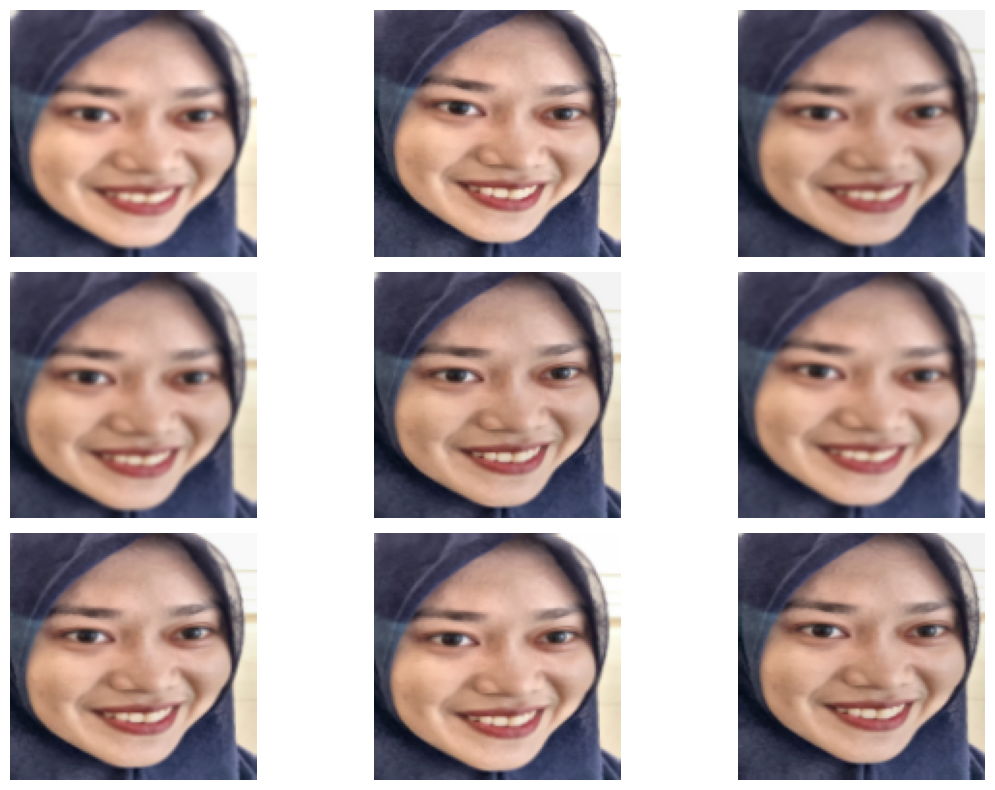

In [14]:
# VISUALISASI HASIL AUGMENTASI

import matplotlib.pyplot as plt
import numpy as np

# ambil 1 gambar sample
img_test = x_train[0]

# ubah shape jadi batch
img_test = np.expand_dims(
    img_test,
    axis=0
)

# generate augmentasi
aug_iter = datagen.flow(
    img_test,
    batch_size=1
)

plt.figure(figsize=(12,8))
for i in range(9):

    # ambil hasil augmentasi
    batch = next(aug_iter)
    aug_img = batch[0]
    plt.subplot(3,3,i+1)
    plt.imshow(aug_img)
    plt.axis("off")
plt.tight_layout()
plt.show()

In [15]:
# Menghitung jumlah data pada setiap label di dataset

unique, counts = np.unique(names, return_counts = True)
for label, total in zip(unique, counts):
    
    print(f"{label:<20} : {total} images")

print("Total class :", len(unique))
print("Total image :", np.sum(counts))

Faza Humairah        : 105 images
Jabbal Akbar         : 105 images
Muhammad Alif        : 104 images
Muhammad Heikal Fasya : 105 images
Muhammad Rizki Arta Maulana : 105 images
Muhammad Zahrul Ath Thariq : 105 images
Nabila Balqis        : 105 images
Natasya Babulrhaiyan : 105 images
Nur Fadhillah Zulfi  : 105 images
Putri Al Violy       : 103 images
Rahmat Isma Hidayat  : 105 images
Riski Maulani        : 102 images
Salesya Al Fatila    : 103 images
Suci Wildani Rizka   : 105 images
Syariqul Husni       : 105 images
Syifaurrahman        : 104 images
Tasya Anisa          : 105 images
Urfi Shanda          : 105 images
Vivi Jumilia Hikmah  : 105 images
Zuyyin Zafirah       : 105 images
Total class : 20
Total image : 2091


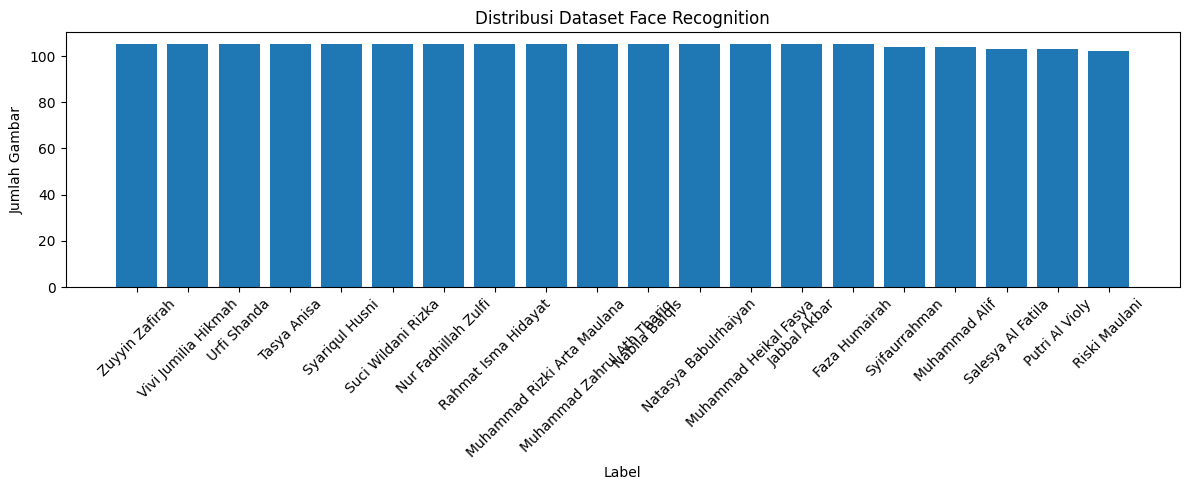

Total class : 20
Total image : 2091


In [16]:
# BALANCING DATA
# Visualisasi distribusi dataset

import matplotlib.pyplot as plt
import numpy as np

# hitung jumlah data
unique, counts = np.unique(
    names,
    return_counts=True
)

# sorting terbesar -> terkecil
sorted_idx = np.argsort(counts)[::-1]

unique = unique[sorted_idx]
counts = counts[sorted_idx]

plt.figure(figsize=(12,5))
plt.bar(unique, counts)
plt.xticks(rotation=45)
plt.xlabel("Label")
plt.ylabel("Jumlah Gambar")
plt.title("Distribusi Dataset Face Recognition")
plt.tight_layout()
plt.show()

print("Total class :", len(unique))
print("Total image :", np.sum(counts))

In [17]:
# Menampilkan jumlah kelas dan nama seluruh kelas/label pada dataset

print(f"Number of classes : {len(labels)}")
print("\nClass Labels :")

for i, label in enumerate(labels):
    print(f"{i} : {label}")

Number of classes : 20

Class Labels :
0 : Faza Humairah
1 : Jabbal Akbar
2 : Muhammad Alif
3 : Muhammad Heikal Fasya
4 : Muhammad Rizki Arta Maulana
5 : Muhammad Zahrul Ath Thariq
6 : Nabila Balqis
7 : Natasya Babulrhaiyan
8 : Nur Fadhillah Zulfi
9 : Putri Al Violy
10 : Rahmat Isma Hidayat
11 : Riski Maulani
12 : Salesya Al Fatila
13 : Suci Wildani Rizka
14 : Syariqul Husni
15 : Syifaurrahman
16 : Tasya Anisa
17 : Urfi Shanda
18 : Vivi Jumilia Hikmah
19 : Zuyyin Zafirah


In [18]:
# Menampilkan label numerik hasil encoding nama peserta

print("Label Mapping :")
for i, label in enumerate(labels):
    print(f"{label} -> {i}")

Label Mapping :
Faza Humairah -> 0
Jabbal Akbar -> 1
Muhammad Alif -> 2
Muhammad Heikal Fasya -> 3
Muhammad Rizki Arta Maulana -> 4
Muhammad Zahrul Ath Thariq -> 5
Nabila Balqis -> 6
Natasya Babulrhaiyan -> 7
Nur Fadhillah Zulfi -> 8
Putri Al Violy -> 9
Rahmat Isma Hidayat -> 10
Riski Maulani -> 11
Salesya Al Fatila -> 12
Suci Wildani Rizka -> 13
Syariqul Husni -> 14
Syifaurrahman -> 15
Tasya Anisa -> 16
Urfi Shanda -> 17
Vivi Jumilia Hikmah -> 18
Zuyyin Zafirah -> 19


In [19]:
# ==========================================
# CNN MODEL ARCHITECTURE
# ==========================================

from tensorflow.keras.models import Sequential

from tensorflow.keras.layers import (
    Conv2D,
    MaxPooling2D,
    Dense,
    Dropout,
    BatchNormalization,
    GlobalAveragePooling2D
)

from tensorflow.keras.regularizers import l2

import tensorflow as tf

# ==========================================
# CNN MODEL
# ==========================================
def cnn_model(input_shape):
    
    model = Sequential()

    # BLOCK 1
    model.add(Conv2D(
        32,
        (3,3),
        padding="same",
        activation="relu",
        input_shape=input_shape
    ))

    model.add(BatchNormalization())

    model.add(Conv2D(
        32,
        (3,3),
        padding="same",
        activation="relu"
    ))

    model.add(BatchNormalization())

    model.add(MaxPooling2D((2,2)))

    model.add(Dropout(0.2))

    # BLOCK 2
    model.add(Conv2D(
        64,
        (3,3),
        padding="same",
        activation="relu"
    ))

    model.add(BatchNormalization())

    model.add(Conv2D(
        64,
        (3,3),
        padding="same",
        activation="relu"
    ))

    model.add(BatchNormalization())

    model.add(MaxPooling2D((2,2)))

    model.add(Dropout(0.2))

    # CLASSIFIER
    model.add(GlobalAveragePooling2D())

    model.add(Dense(
        128,
        activation="relu"
    ))

    model.add(Dropout(0.3))

    model.add(Dense(
        len(labels),
        activation="softmax"
    ))

    model.compile(

        optimizer=tf.keras.optimizers.Adam(
            learning_rate=0.0005
        ),

        loss='categorical_crossentropy',

        metrics=['accuracy']
    )

    return model

In [20]:
# ==========================================
# TRAINING MODEL CNN
# ==========================================

from tensorflow.keras.callbacks import (
    EarlyStopping,
    ReduceLROnPlateau,
    ModelCheckpoint
)

# ==========================================
# INPUT SHAPE
# ==========================================

input_shape = x_train[0].shape

# ==========================================
# HYPERPARAMETER
# ==========================================

EPOCHS = 30

BATCH_SIZE = 32

# ==========================================
# CALLBACK
# ==========================================

# early stopping
early_stop = EarlyStopping(

    monitor='val_accuracy',

    patience=7,

    restore_best_weights=True,

    verbose=1
)

# reduce learning rate otomatis
reduce_lr = ReduceLROnPlateau(

    monitor='val_loss',

    factor=0.5,

    patience=2,

    verbose=1,

    min_lr=1e-6
)

# save model terbaik
checkpoint = ModelCheckpoint(

    "best_model.keras",

    monitor='val_accuracy',

    save_best_only=True,

    verbose=1
)

# ==========================================
# BUILD MODEL
# ==========================================

model = cnn_model(input_shape)

# ==========================================
# TRAINING MODEL
# ==========================================

history = model.fit(

    datagen.flow(
        x_train,
        y_train,
        batch_size=BATCH_SIZE,
        shuffle=True
    ),

    validation_data=(
        x_test,
        y_test
    ),

    epochs=EPOCHS,

    callbacks=[
        early_stop,
        reduce_lr,
        checkpoint
    ],

    verbose=1
)

d:\FaceAttend_VC\venv\lib\site-packages\keras\src\layers\convolutional\base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Epoch 1/30
53/53 ━━━━━━━━━━━━━━━━━━━━ 0s 1s/step - accuracy: 0.2099 - loss: 2.7149
Epoch 1: val_accuracy improved from None to 0.05012, saving model to best_model.keras
53/53 ━━━━━━━━━━━━━━━━━━━━ 81s 1s/step - accuracy: 0.3260 - loss: 2.3886 - val_accuracy: 0.0501 - val_loss: 3.0030 - learning_rate: 5.0000e-04
Epoch 2/30
53/53 ━━━━━━━━━━━━━━━━━━━━ 0s 1s/step - accuracy: 0.5338 - loss: 1.6958
Epoch 2: val_accuracy did not improve from 0.05012
53/53 ━━━━━━━━━━━━━━━━━━━━ 71s 1s/step - accuracy: 0.5724 - loss: 1.5732 - val_accuracy: 0.0501 - val_loss: 3.1526 - learning_rate: 5.0000e-04
Epoch 3/30
53/53 ━━━━━━━━━━━━━━━━━━━━ 0s 1s/step - accuracy: 0.6333 - loss: 1.3018
Epoch 3: ReduceLROnPlateau reducing learning rate to 0.0002500000118743628.

Epoch 3: val_accuracy did not improve from 0.05012
53/53 ━━━━━━━━━━━━━━━━━━━━ 71s 1s/step - accuracy: 0.6591 - loss: 1.2060 - val_accuracy: 0.0501 - val_loss: 3.4721 - learning_rate: 5.0000e-04
Epoch 4/30
53/53 ━━━━━━━━━━━━━━━━━━━━ 0s 1s/step - accura

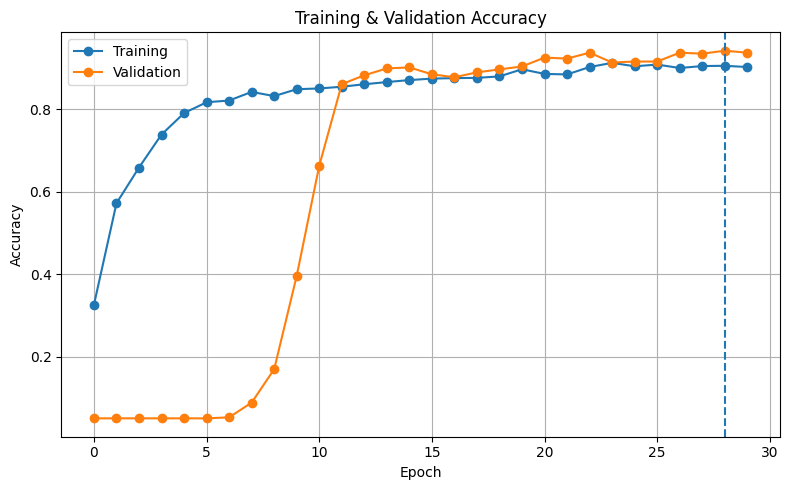


Best Epoch : 29
Best Validation val_accuracy : 0.9427


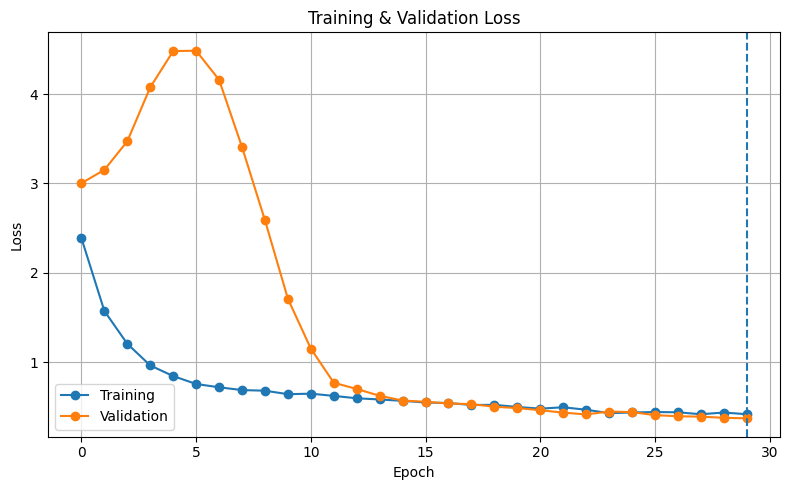


Best Epoch : 30
Best Validation val_loss : 0.3715


In [21]:
# ==========================================
# VISUALISASI HASIL TRAINING CNN
# ==========================================

import matplotlib.pyplot as plt
import numpy as np

def evaluate_model(history):

    metrics = [
        ['accuracy', 'val_accuracy'],
        ['loss', 'val_loss']
    ]

    titles = [
        'Training & Validation Accuracy',
        'Training & Validation Loss'
    ]

    for i, metric in enumerate(metrics):

        plt.figure(figsize=(8,5))

        # training
        plt.plot(
            history.history[metric[0]],
            marker='o',
            label='Training'
        )

        # validation
        plt.plot(
            history.history[metric[1]],
            marker='o',
            label='Validation'
        )

        # best epoch
        if metric[0] == 'accuracy':

            best_epoch = np.argmax(
                history.history[metric[1]]
            )

            best_value = np.max(
                history.history[metric[1]]
            )

        else:

            best_epoch = np.argmin(
                history.history[metric[1]]
            )

            best_value = np.min(
                history.history[metric[1]]
            )

        plt.axvline(
            best_epoch,
            linestyle='--'
        )

        plt.xlabel('Epoch')

        plt.ylabel(metric[0].capitalize())

        plt.title(titles[i])

        plt.legend(loc='best')

        plt.grid(True)

        plt.tight_layout()

        plt.show()

        # ==================================
        # INFO METRIC
        # ==================================

        print("\n==========================")

        print(f"Best Epoch : {best_epoch+1}")

        print(
            f"Best Validation "
            f"{metric[1]} : "
            f"{best_value:.4f}"
        )

        print("==========================")

# ==========================================
# TAMPILKAN HASIL TRAINING
# ==========================================

evaluate_model(history)

In [26]:
model.save("model-cnn-facerecognition.keras")

In [22]:
# Melakukan prediksi pada data testing menggunakan model CNN

# prediksi probabilitas
y_pred = model.predict(
    x_test,
    verbose=0
)

# class hasil prediksi
y_pred_classes = np.argmax(
    y_pred,
    axis=1
)

# class label sebenarnya
y_true = np.argmax(
    y_test,
    axis=1
)

# confidence score
confidence_scores = np.max(
    y_pred,
    axis=1
)

print("[INFO] Prediksi selesai.")

print("Total testing data :", len(y_true))

[INFO] Prediksi selesai.
Total testing data : 419


In [23]:
# CONFUSION MATRIX

# ==========================================
# CONFUSION MATRIX
# ==========================================

import itertools
import numpy as np
import matplotlib.pyplot as plt

def plot_confusion_matrix(

    cm,

    classes,

    normalize=False,

    title='Confusion Matrix',

    cmap=plt.cm.Blues
):

    # ======================================
    # NORMALISASI
    # ======================================

    if normalize:

        cm = cm.astype('float') / cm.sum(
            axis=1
        )[:, np.newaxis]

    # ======================================
    # HITUNG AKURASI
    # ======================================

    accuracy = np.trace(cm) / np.sum(cm)

    # ======================================
    # VISUALISASI
    # ======================================

    plt.figure(figsize=(12,10))

    plt.imshow(
        cm,
        interpolation='nearest',
        cmap=cmap
    )

    plt.title(
        f"{title}\nAccuracy: {accuracy:.4f}"
    )

    plt.colorbar()

    tick_marks = np.arange(len(classes))

    plt.xticks(
        tick_marks,
        classes,
        rotation=90,
        fontsize=8
    )

    plt.yticks(
        tick_marks,
        classes,
        fontsize=8
    )

    # ======================================
    # TEXT MATRIX
    # ======================================

    fmt = '.2f' if normalize else 'd'

    thresh = cm.max() / 2.

    for i, j in itertools.product(
        range(cm.shape[0]),
        range(cm.shape[1])
    ):

        plt.text(

            j,
            i,

            format(cm[i, j], fmt),

            horizontalalignment="center",

            color=(
                "white"
                if cm[i, j] > thresh
                else "black"
            ),

            fontsize=8
        )

    # ======================================
    # LABEL
    # ======================================

    plt.ylabel('True Label')

    plt.xlabel('Predicted Label')

    plt.subplots_adjust(
        bottom=0.25,
        left=0.25
    )

    plt.tight_layout()

    plt.show()

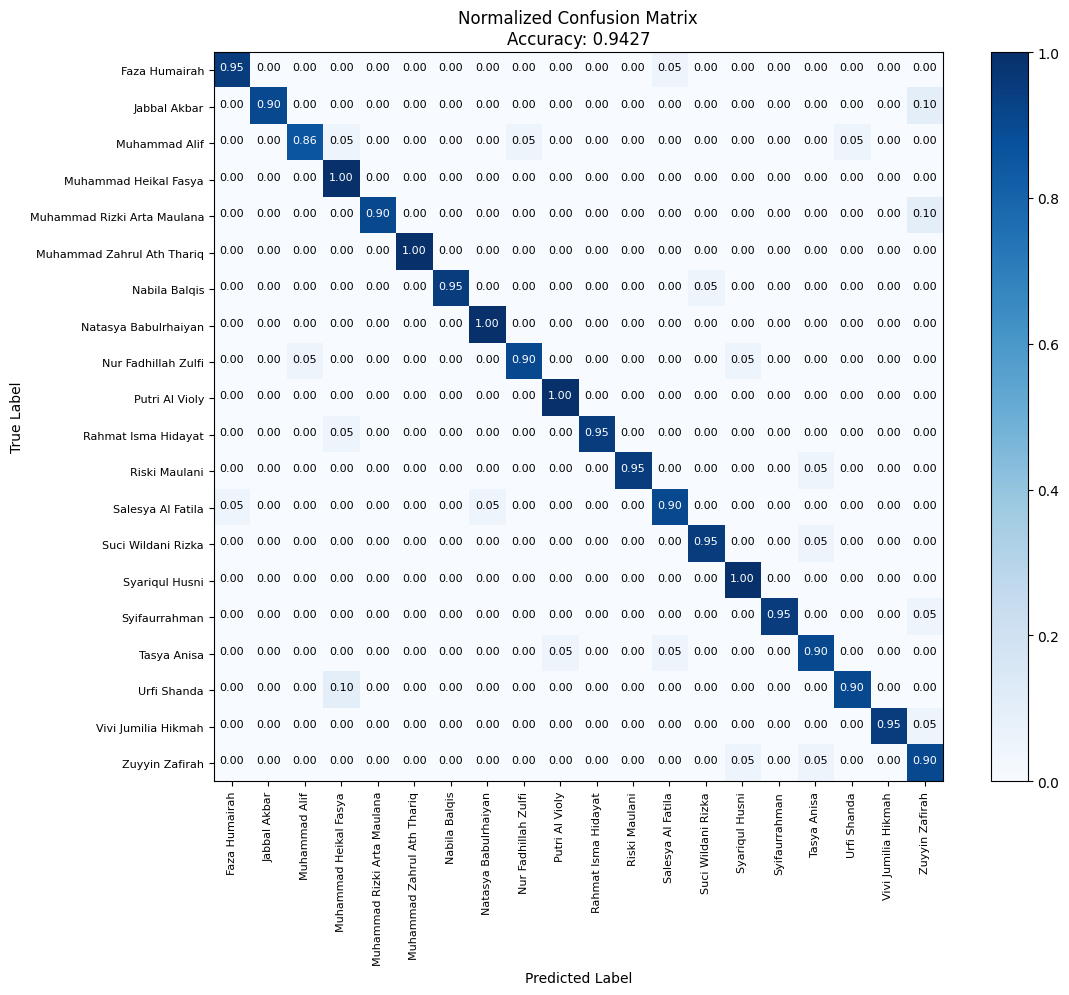


Accuracy : 0.9427


In [24]:
from sklearn.metrics import confusion_matrix
import numpy as np

# hitung confusion matrix
cnf_matrix = confusion_matrix(

    y_true,

    y_pred_classes
)

# menampilkan angka desimal
np.set_printoptions(precision=2)

# visualisasi confusion matrix
plot_confusion_matrix(

    cnf_matrix,

    classes=labels,

    normalize=True,

    title='Normalized Confusion Matrix'
)

accuracy = np.trace(cnf_matrix) / np.sum(cnf_matrix)

print(f"\nAccuracy : {accuracy:.4f}")


In [25]:
# Menampilkan hasil evaluasi klasifikasi model CNN
# CLASSIFICATION REPORT

from sklearn.metrics import (
    classification_report,
    accuracy_score
)

# hitung accuracy
accuracy = accuracy_score(
    y_true,
    y_pred_classes
)

print("\n==========================")
print("HASIL EVALUASI MODEL CNN")
print("==========================")

print(f"Accuracy : {accuracy:.4f}")

print("\nClassification Report:\n")

# classification report
report = classification_report(

    y_true,

    y_pred_classes,

    target_names=labels,

    zero_division=0
)

print(report)

print("==========================")


HASIL EVALUASI MODEL CNN
Accuracy : 0.9427

Classification Report:

                             precision    recall  f1-score   support

              Faza Humairah       0.95      0.95      0.95        21
               Jabbal Akbar       1.00      0.90      0.95        21
              Muhammad Alif       0.95      0.86      0.90        21
      Muhammad Heikal Fasya       0.84      1.00      0.91        21
Muhammad Rizki Arta Maulana       1.00      0.90      0.95        21
 Muhammad Zahrul Ath Thariq       1.00      1.00      1.00        21
              Nabila Balqis       1.00      0.95      0.98        21
       Natasya Babulrhaiyan       0.95      1.00      0.98        21
        Nur Fadhillah Zulfi       0.95      0.90      0.93        21
             Putri Al Violy       0.95      1.00      0.98        21
        Rahmat Isma Hidayat       1.00      0.95      0.98        21
              Riski Maulani       1.00      0.95      0.97        20
          Salesya Al Fatila      

In [27]:
import cv2
import numpy as np
import pickle

from mtcnn import MTCNN

from tensorflow.keras.models import load_model

# ==========================================
# LOAD MODEL
# ==========================================

detector = MTCNN()

model = load_model(
    "model-cnn-facerecognition.keras"
)

# load label encoder
with open(
    "Label_encoder_cnn.pickle",
    "rb"
) as f:

    le = pickle.load(f)

print("[INFO] Finish load model...")

# ==========================================
# OPEN CAMERA
# ==========================================

cap = cv2.VideoCapture(0)

while cap.isOpened():

    ret, frame = cap.read()

    if not ret:
        break

    # ======================================
    # BGR -> RGB
    # ======================================

    rgb = cv2.cvtColor(
        frame,
        cv2.COLOR_BGR2RGB
    )

    # ======================================
    # DETECT FACE
    # ======================================

    results = detector.detect_faces(rgb)

    # filter confidence
    results = [
        r for r in results
        if r['confidence'] >= 0.8
    ]

    for result in results:

        x, y, w, h = result['box']

        x = max(0, x)
        y = max(0, y)

        # ==================================
        # LANDMARK
        # ==================================

        try:

            keypoints = result['keypoints']

            left_eye = keypoints['left_eye']
            right_eye = keypoints['right_eye']

        except:
            continue

        # ==================================
        # FACE ALIGNMENT
        # ==================================

        dx = right_eye[0] - left_eye[0]

        dy = right_eye[1] - left_eye[1]

        angle = np.degrees(
            np.arctan2(dy, dx)
        )

        center = (
            int((left_eye[0] + right_eye[0]) / 2),
            int((left_eye[1] + right_eye[1]) / 2)
        )

        M = cv2.getRotationMatrix2D(
            center,
            angle,
            1.0
        )

        aligned = cv2.warpAffine(
            rgb,
            M,
            (rgb.shape[1], rgb.shape[0])
        )

        # ==================================
        # PADDING FACE
        # ==================================

        pad = int(min(w, h) * 0.12)

        x1 = max(0, x-pad)
        y1 = max(0, y-pad)

        x2 = min(aligned.shape[1], x+w+pad)
        y2 = min(aligned.shape[0], y+h+pad)

        # crop wajah
        face = aligned[y1:y2, x1:x2]

        if face.size == 0:
            continue

        # ==================================
        # CLAHE
        # ==================================

        lab = cv2.cvtColor(
            face,
            cv2.COLOR_RGB2LAB
        )

        l, a, b = cv2.split(lab)

        clahe = cv2.createCLAHE(
            clipLimit=2.0,
            tileGridSize=(8,8)
        )

        l = clahe.apply(l)

        lab = cv2.merge((l,a,b))

        face = cv2.cvtColor(
            lab,
            cv2.COLOR_LAB2RGB
        )

        # ==================================
        # RESIZE
        # ==================================

        face = cv2.resize(
            face,
            (128,128),
            interpolation=cv2.INTER_AREA
        )

        # ==================================
        # NORMALISASI
        # ==================================

        face = face.astype("float32") / 255.0

        # reshape CNN
        face = face.reshape(
            1,
            128,
            128,
            3
        )

        # ==================================
        # PREDICTION
        # ==================================

        result_pred = model.predict(
            face,
            verbose=0
        )

        predictions = result_pred[0]

        # TOP 1
        top1_idx = np.argmax(predictions)

        top1_conf = predictions[top1_idx] * 100

        # TOP 2
        top2_conf = np.partition(
            predictions,
            -2
        )[-2] * 100

        # selisih confidence
        difference = top1_conf - top2_conf

        print(
            le.classes_[top1_idx],
            top1_conf,
            "| diff :",
            difference
        )

        # ==================================
        # THRESHOLD
        # ==================================

        if top1_conf > 70 and difference > 10:

            label_text = "%s (%.2f%%)" % (
                le.classes_[top1_idx],
                top1_conf
            )

        else:

            label_text = "Unknown"

        # ==================================
        # DRAWING
        # ==================================

        cv2.rectangle(
            frame,
            (x1, y1),
            (x2, y2),
            (0,255,255),
            2
        )

        cv2.putText(
            frame,
            label_text,
            (x1, y1-10),
            cv2.FONT_HERSHEY_SIMPLEX,
            0.7,
            (0,255,255),
            2
        )

    # ======================================
    # SHOW FRAME
    # ======================================

    cv2.imshow(
        "Face Recognition",
        frame
    )

    # tombol keluar
    if cv2.waitKey(10) & 0xFF == ord('q'):
        break

cap.release()

cv2.destroyAllWindows()

[INFO] Finish load model...
Putri Al Violy 52.59415 | diff : 30.919264
Putri Al Violy 56.023067 | diff : 22.249935
Putri Al Violy 49.08166 | diff : 15.906567
Putri Al Violy 43.877037 | diff : 0.79911804
Putri Al Violy 49.999702 | diff : 17.780792
Muhammad Zahrul Ath Thariq 46.317715 | diff : 14.02586
Putri Al Violy 37.024643 | diff : 0.11993408
Putri Al Violy 49.4207 | diff : 20.068613
Putri Al Violy 43.818333 | diff : 12.263714
Muhammad Zahrul Ath Thariq 36.868866 | diff : 9.297924
Muhammad Zahrul Ath Thariq 36.663548 | diff : 3.9907036
Putri Al Violy 38.287235 | diff : 7.9823856
Putri Al Violy 45.480995 | diff : 18.648811
Putri Al Violy 40.894093 | diff : 11.765139
Putri Al Violy 41.917686 | diff : 14.751728
Putri Al Violy 37.613834 | diff : 10.547552
Putri Al Violy 39.80033 | diff : 12.2201
Muhammad Zahrul Ath Thariq 38.912003 | diff : 11.9375305
Muhammad Zahrul Ath Thariq 41.285057 | diff : 22.12441
Muhammad Zahrul Ath Thariq 40.621883 | diff : 14.743961
Muhammad Zahrul Ath Thariq 